<a href="https://colab.research.google.com/github/Jesus4antonio/Probabilidad/blob/main/Unidad5/Regresi%C3%B3n_lineal_y_correlaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROBABILIDAD Y ESTADISTICA

## UNIDAD 5

### FACILITADOR: Jose Gabriel Rodruguez

### Alumna: Jesus Antonio Sanchez Aguilar

## **Regresión lineal y correlación**


ANÁLISIS COMPLETO: grupo1.csv


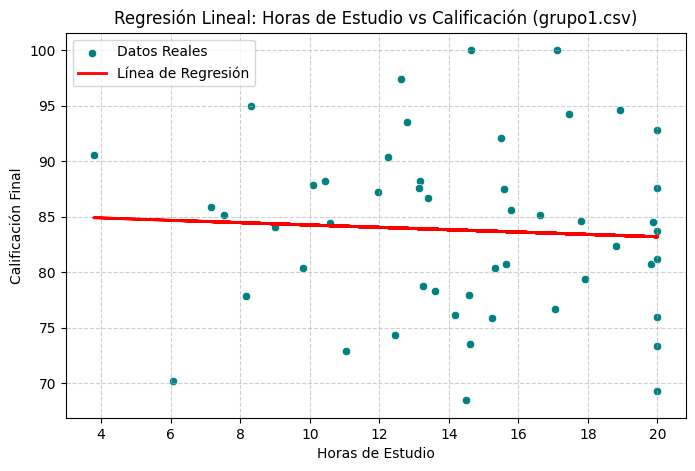

Ecuación de la línea: y = -0.1061x + 85.3107
Coeficiente de Correlación de Pearson (r): -0.0571
Coeficiente de Determinación (R²): 0.0033

--- RESPUESTAS PARA EL GRUPO1.CSV ---
1. Interpretación: Por cada hora adicional de estudio dedicada, la calificación
   final aumenta, en promedio, -0.1061 puntos.
2. El coeficiente r de -0.0571 indica una relación débil y positiva.
3. Significancia: NO parece ser significativo (mucha dispersión).
4. La confiabilidad del modelo es Baja, ya que explica el 0.33%
   de la variabilidad de las calificaciones.

ANÁLISIS COMPLETO: grupo2.csv


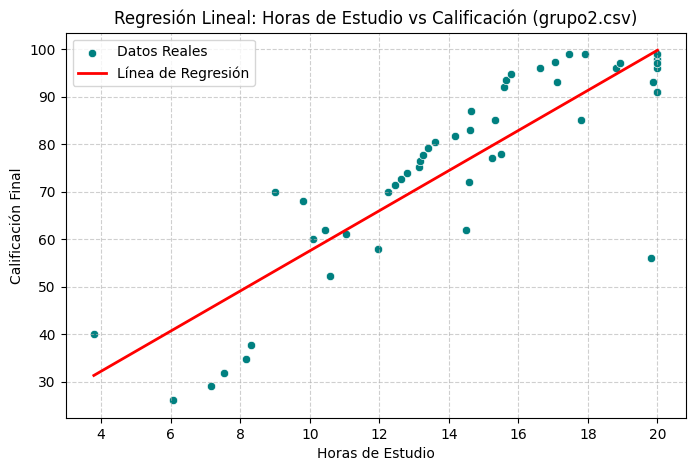

Ecuación de la línea: y = 4.2227x + 15.3075
Coeficiente de Correlación de Pearson (r): 0.8620
Coeficiente de Determinación (R²): 0.7430

--- RESPUESTAS PARA EL GRUPO2.CSV ---
1. Interpretación: Por cada hora adicional de estudio dedicada, la calificación
   final aumenta, en promedio, 4.2227 puntos.
2. El coeficiente r de 0.8620 indica una relación fuerte y positiva.
3. Significancia: SÍ es significativo.
4. La confiabilidad del modelo es Media, ya que explica el 74.30%
   de la variabilidad de las calificaciones.

ANÁLISIS COMPLETO: grupo3.csv


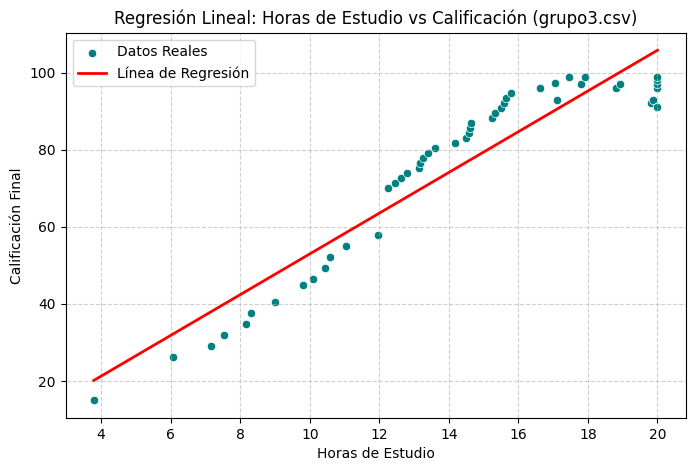

Ecuación de la línea: y = 5.2857x + 0.1081
Coeficiente de Correlación de Pearson (r): 0.9422
Coeficiente de Determinación (R²): 0.8878

--- RESPUESTAS PARA EL GRUPO3.CSV ---
1. Interpretación: Por cada hora adicional de estudio dedicada, la calificación
   final aumenta, en promedio, 5.2857 puntos.
2. El coeficiente r de 0.9422 indica una relación fuerte y positiva.
3. Significancia: SÍ es significativo.
4. La confiabilidad del modelo es Alta, ya que explica el 88.78%
   de la variabilidad de las calificaciones.

--- Conclusión General ---
Se observa que la relación entre el tiempo de estudio y el rendimiento varía entre grupos.
Mientras que en algunos grupos el tiempo de estudio es un predictor casi perfecto (R² alto),
en otros existen factores externos o ruido que debilitan la precisión del modelo lineal.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr

# Lista de archivos exactos proporcionados
archivos = ["grupo1.csv", "grupo2.csv", "grupo3.csv"]

def analizar_y_responder(archivo):
    try:
        # 1. Carga y Exploración de Datos
        df = pd.read_csv(archivo)

        print("\n" + "="*70)
        print(f"ANÁLISIS COMPLETO: {archivo}")
        print("="*70)

        # 2. Modelo de Regresión Lineal
        X = df[['HorasEstudio']]
        y = df['Calificacion']
        modelo = LinearRegression()
        modelo.fit(X, y)

        # 3. Cálculo de métricas y cuantificación de la relación
        pendiente = modelo.coef_[0]
        intercepto = modelo.intercept_
        r_cuadrado = modelo.score(X, y)
        corr, _ = pearsonr(df['HorasEstudio'], df['Calificacion'])

        # 4. Visualización de Resultados
        plt.figure(figsize=(8, 5))
        sns.scatterplot(x='HorasEstudio', y='Calificacion', data=df, color='teal', label='Datos Reales')
        plt.plot(df['HorasEstudio'], modelo.predict(X), color='red', linewidth=2, label='Línea de Regresión')
        plt.title(f'Regresión Lineal: Horas de Estudio vs Calificación ({archivo})')
        plt.xlabel('Horas de Estudio')
        plt.ylabel('Calificación Final')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.show()

        # 5. Cuantificación de la relación
        print(f"Ecuación de la línea: y = {pendiente:.4f}x + {intercepto:.4f}")
        print(f"Coeficiente de Correlación de Pearson (r): {corr:.4f}")
        print(f"Coeficiente de Determinación (R²): {r_cuadrado:.4f}")

        # --- RESPUESTAS A LAS PREGUNTAS DEL DOCUMENTO ---
        print(f"\n--- RESPUESTAS PARA EL {archivo.upper()} ---")

        # P1: Interpretación del coeficiente de regresión
        print(f"1. Interpretación: Por cada hora adicional de estudio dedicada, la calificación")
        print(f"   final aumenta, en promedio, {pendiente:.4f} puntos.")

        # P2: Interpretación de r
        fuerza = "fuerte" if abs(corr) > 0.7 else "moderada" if abs(corr) > 0.4 else "débil"
        print(f"2. El coeficiente r de {corr:.4f} indica una relación {fuerza} y positiva.")

        # P3: Significancia estadística
        # Basado en la observación visual y R²
        sig = "SÍ es significativo" if r_cuadrado > 0.5 else "NO parece ser significativo (mucha dispersión)"
        print(f"3. Significancia: {sig}.")

        # P4: Confiabilidad para predecir
        conf = "Alta" if r_cuadrado > 0.8 else "Media" if r_cuadrado > 0.5 else "Baja"
        print(f"4. La confiabilidad del modelo es {conf}, ya que explica el {r_cuadrado*100:.2f}%")
        print(f"   de la variabilidad de las calificaciones.")

    except FileNotFoundError:
        print(f"Error: No se encontró el archivo {archivo}. Asegúrate de que esté en la misma carpeta.")

# Ejecución del programa
for arc in archivos:
    analizar_y_responder(arc)

print("\n--- Conclusión General ---")
print("Se observa que la relación entre el tiempo de estudio y el rendimiento varía entre grupos.")
print("Mientras que en algunos grupos el tiempo de estudio es un predictor casi perfecto (R² alto),")
print("en otros existen factores externos o ruido que debilitan la precisión del modelo lineal.")